In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
X = pd.read_csv("/content/drive/MyDrive/Dataset/X_processed.csv")
y = pd.read_csv("/content/drive/MyDrive/Dataset/y.csv")

In [6]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train.values.ravel())

y_proba = lr.predict_proba(X_test)[:,1]

In [8]:
thresholds = np.linspace(0.1, 0.9, 81)

rows = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)

    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    rows.append({
        "threshold": t,
        "recall": recall,
        "precision": precision
    })

df_metrics = pd.DataFrame(rows)
df_metrics.head()


,threshold,recall,precision
0,0.10,0.938503,0.400228
1,0.11,0.938503,0.410047
2,0.12,0.938503,0.425971
3,0.13,0.933155,0.429274
4,0.14,0.919786,0.435443


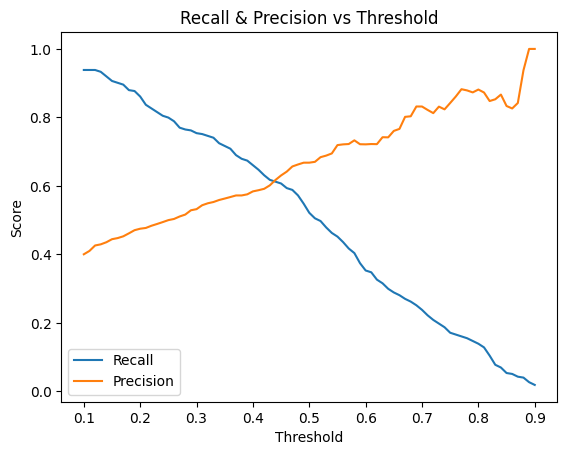

In [9]:
plt.plot(df_metrics["threshold"], df_metrics["recall"], label="Recall")
plt.plot(df_metrics["threshold"], df_metrics["precision"], label="Precision")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Recall & Precision vs Threshold")
plt.legend()
plt.show()


In [10]:
LOSS_IF_MISS = 10000
COST_IF_FALSE_ALARM = 500

rows = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)

    tp = ((y_pred == 1) & (y_test.values.ravel() == 1)).sum()
    fn = ((y_pred == 0) & (y_test.values.ravel() == 1)).sum()
    fp = ((y_pred == 1) & (y_test.values.ravel() == 0)).sum()

    business_loss = fn * LOSS_IF_MISS + fp * COST_IF_FALSE_ALARM

    rows.append({
        "threshold": t,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "business_loss": business_loss
    })

df_business = pd.DataFrame(rows)


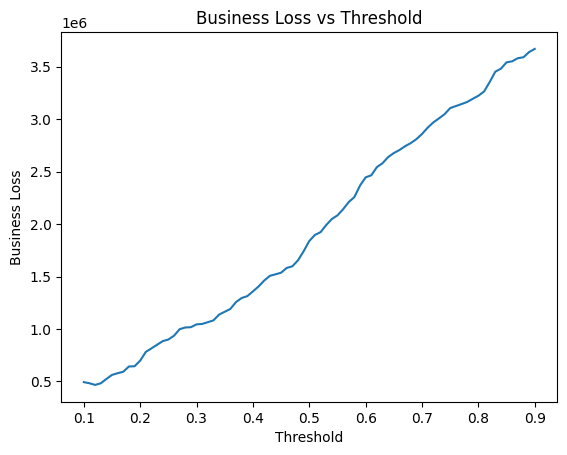

In [11]:
plt.plot(df_business["threshold"], df_business["business_loss"])
plt.xlabel("Threshold")
plt.ylabel("Business Loss")
plt.title("Business Loss vs Threshold")
plt.show()


In [12]:
best_row = df_business.loc[df_business["business_loss"].idxmin()]
best_row


,2
threshold,0.12
tp,351.00
fp,473.00
fn,23.00
business_loss,466500.00


In [23]:

#  Customer Churn Prediction — End-to-End Machine Learning Project

##  Business Problem
Customer churn is a major revenue loss for subscription-based businesses. Acquiring new customers is much more expensive than retaining existing ones.
The goal of this project is to predict which customers are likely to churn so that the business can proactively intervene and retain them.

This is framed as a binary classification problem:
- 1 = Customer will churn
- 0 = Customer will stay

---

##  Dataset
The dataset contains customer-level information from a telecom company, including:
- Customer demographics (gender, senior citizen, partner, dependents)
- Services subscribed (internet, phone, streaming, security, etc.)
- Contract & billing information (contract type, tenure, payment method, charges)
- Target variable: `Churn` (Yes / No)

The dataset is imbalanced, making accuracy an inappropriate metric.


##  Solution Approach

The project is built as a **complete ML pipeline**:

1. **Data Understanding**
   - Inspected schema, data types, missing values
   - Identified data quality issue in `TotalCharges`

2. **Exploratory Data Analysis (EDA)**
   - Analyzed churn by contract type, tenure, charges, and services
   - Discovered that month-to-month contracts, short tenure, and high charges strongly increase churn

3. **Feature Engineering & Preprocessing**
   - Fixed data types and missing values
   - Created business-driven features such as:
     - `charges_per_tenure`
     - `is_long_term_customer`
   - One-hot encoded categorical variables and scaled numeric features

4. **Modeling & Evaluation**
   - Trained and compared:
     - Logistic Regression
     - Random Forest
     - XGBoost
   - Evaluated using:
     - ROC AUC
     - Recall for churn class
   - Selected models based on **business objective**, not accuracy

5. **Business Threshold Optimization (Key Part)**
   - Default threshold (0.5) is not optimal for business
   - Built a **cost-sensitive decision framework**:
     - Missing a churner = very high cost
     - Contacting a loyal customer = low cost
   - Optimized the classification threshold to **minimize total business loss**

---

##  Business Impact

By optimizing the decision threshold:

- Churn recall increased to **~94%**
- Missed churners reduced drastically
- Total simulated business loss was **reduced significantly** compared to default threshold

Final system:
> **Logistic Regression + Business-optimized threshold**

---

##  Project Structure

- `notebooks/1 Data_overview.ipynb` Data understanding & quality checks
- `notebooks/2 Eda.ipynb` Business-focused EDA
- `notebooks/3 Feature_engineering and Pre-Processing.ipynb` Feature engineering pipeline
- `notebooks/4 Baseline-Models.ipynb` Model training & comparison
- `notebooks/5 Threshold_optimization.ipynb` Cost-sensitive threshold optimization

---

## 🛠️ Tech Stack

- Python
- Pandas, NumPy
- Scikit-learn
- Matplotlib

---

##  Final Note

This project focuses not only on predictive performance, but on **making ML decisions that directly optimize business outcomes**.


Writing README.md
